# Telecom Customer Churn - Exploratory Data Analysis



## 1. Data Overview
[Phase 1 ]

## 2. Demographic Analysis
[Phase 2 ]

## 3. Service Subscription Patterns
[Phase 3 ]

## 4. Tenure & Contract Analysis ⭐
[Phase 4  - most important]

## 5. Financial Analysis
[Phase 5 ]

## 6. Multivariate Analysis
[Phase 6 ]

## 7. Key Insights & Business Recommendations
[Phase 7]

## 8. Next Steps
- Feature engineering based on findings
- Customer segmentation
- Churn prediction modeling

# Data Overview (Phase 1)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r'D:\Challa Shabd Swaroop\SHABD\Project_Portfolio\telecom-customer-intelligence\data\processed\cleaned_data.csv')

# Number of customers

In [2]:
df.shape[0]

7043

# Number of Features/Attributes

In [5]:
df.shape[1]-2 # excluding the target variable and customerID column

19

# Output Variable and its summary.

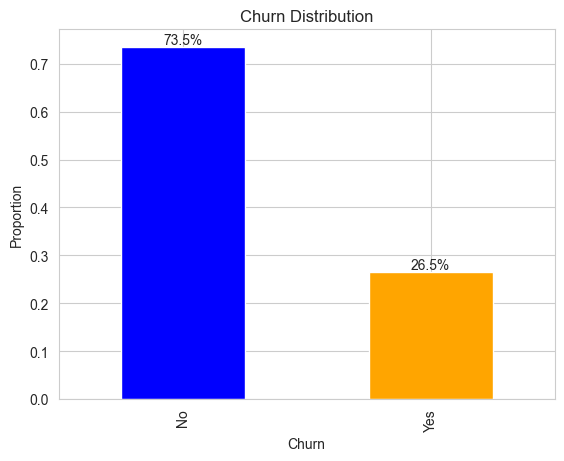

In [23]:

ax = df['Churn'].value_counts(normalize=True).plot(
    kind='bar',
    title='Churn Distribution',
    color=['blue', 'orange']
)

# Add percentage labels
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()*100:.1f}%',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.ylabel('Proportion')
plt.show()

# clearly we can see class imbalance of nearly 2.77:1 times negative to positive class

# Lets explore other columns First Numerical columns or measures and then categorical or dimensions

In [13]:
df_numerical = df.select_dtypes(include=[np.number])
df_categorical = df.select_dtypes(include=['string'])
# dropping customerID column as it is not useful for analysis
df_categorical = df_categorical.drop(columns=['customerID'])

In [14]:
df_numerical.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SeniorCitizen   7043 non-null   int64  
 1   tenure          7043 non-null   int64  
 2   MonthlyCharges  7043 non-null   float64
 3   TotalCharges    7043 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 220.2 KB


In [15]:
df_numerical.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# senior citizen is a binary type as it has only 0 and 1 values however due it being integer data type we can see five point summary as measure.lets plot histplot and boxplot for tenure,MonthlyCharges and TotalCharges

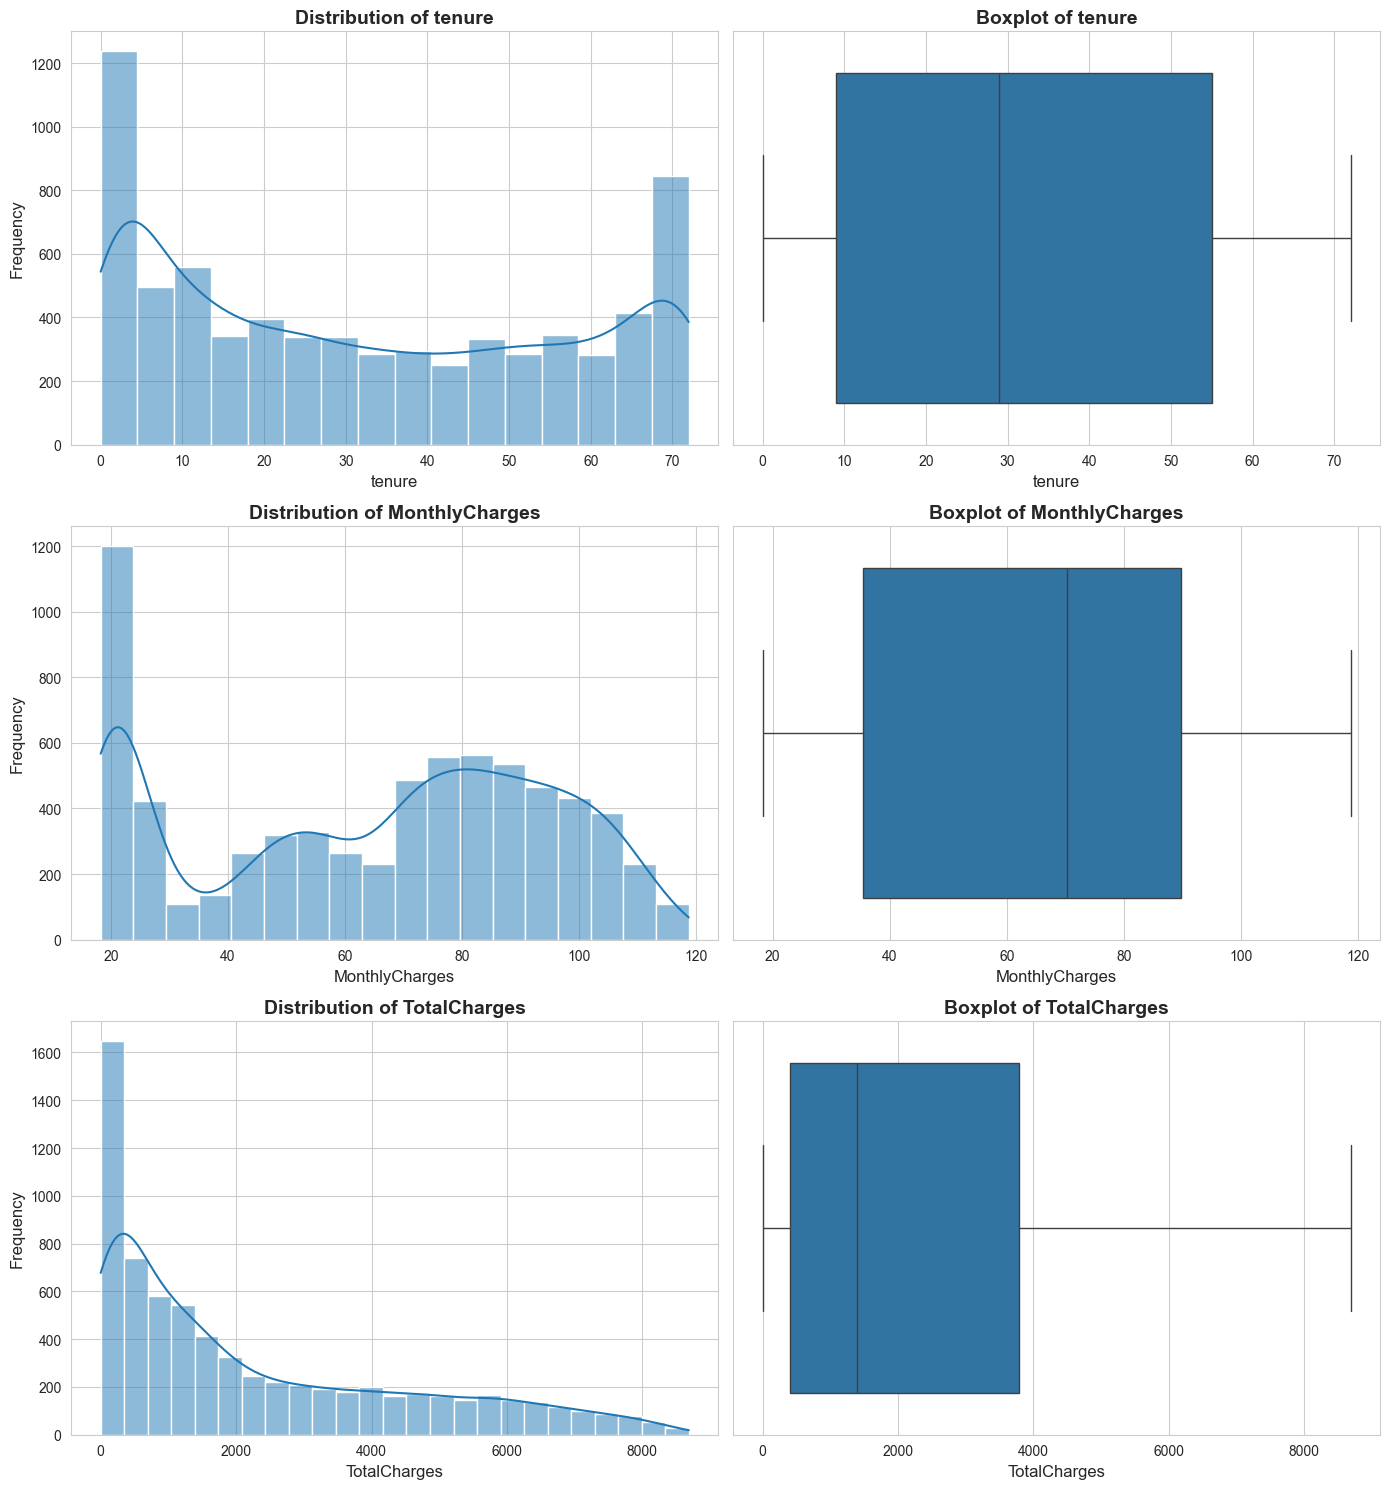

In [16]:
# Set style
sns.set_style("whitegrid")

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(14, 15))

for i, col in enumerate(numerical_cols):

    # Histogram
    sns.histplot(
        data=df_numerical,
        x=col,
        kde=True,
        ax=axes[i, 0]
    )

    axes[i, 0].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i, 0].set_xlabel(col, fontsize=12)
    axes[i, 0].set_ylabel('Frequency', fontsize=12)

    # Boxplot
    sns.boxplot(
        x=df_numerical[col],
        ax=axes[i, 1]
    )

    axes[i, 1].set_title(f'Boxplot of {col}', fontsize=14, fontweight='bold')
    axes[i, 1].set_xlabel(col, fontsize=12)

plt.tight_layout()
plt.show()

# Observation: No significant outliers were detected in tenure, MonthlyCharges, or TotalCharges using boxplot analysis. MonthlyCharges exhibits a bimodal distribution, suggesting the presence of distinct customer service tiers. TotalCharges is positively skewed, which is expected as it accumulates over customer tenure. The distributions appear consistent with business expectations and do not require outlier treatment prior to modeling.

In [18]:
df_categorical.columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [19]:
categorical_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]
for col in categorical_cols:
    print(f"\n{col}")
    print(df_categorical[col].value_counts())
    print(df_categorical[col].value_counts(normalize=True) * 100)


gender
gender
Male      3555
Female    3488
Name: count, dtype: int64
gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Partner
No     51.69672
Yes    48.30328
Name: proportion, dtype: float64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
Dependents
No     70.041176
Yes    29.958824
Name: proportion, dtype: float64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
PhoneService
Yes    90.316626
No      9.683374
Name: proportion, dtype: float64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
MultipleLines
No                  48.132898
Yes                 42.183729
No phone service     9.683374
Name: proportion, dtype: float64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
InternetService
F

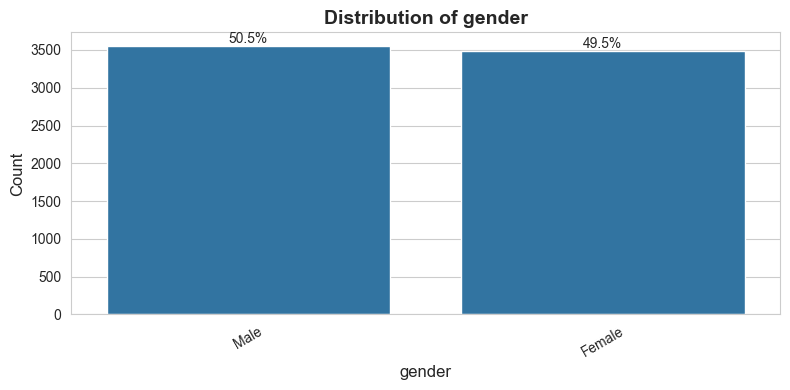

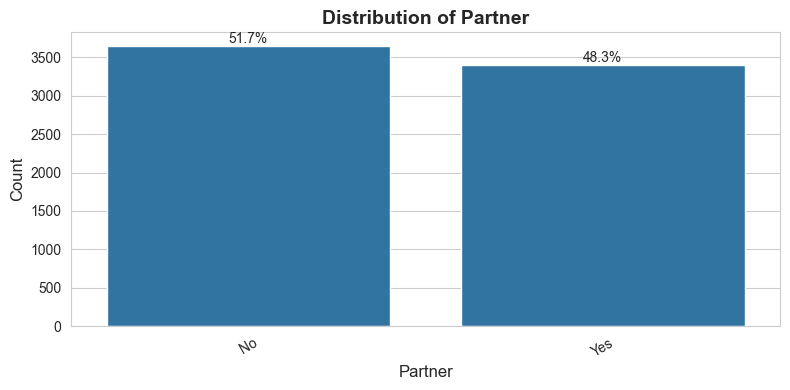

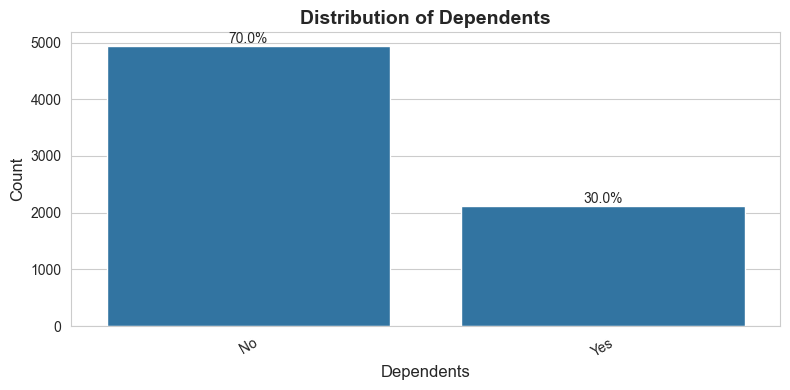

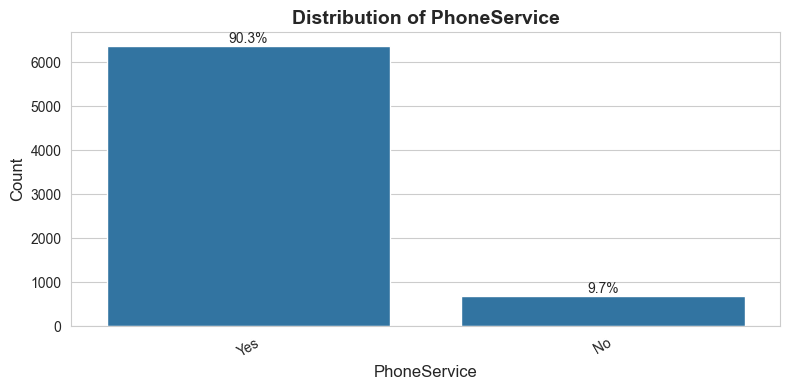

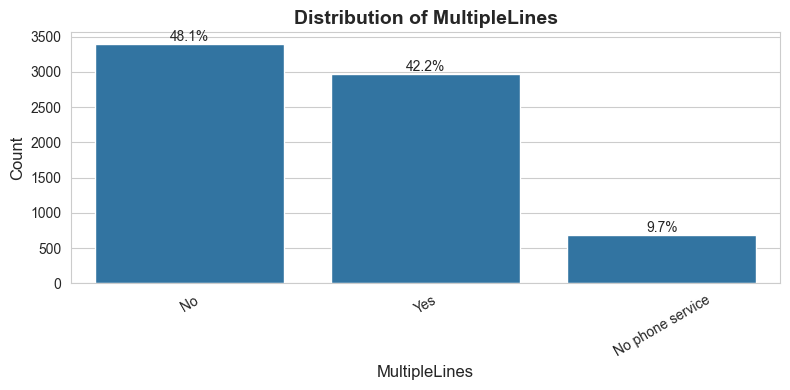

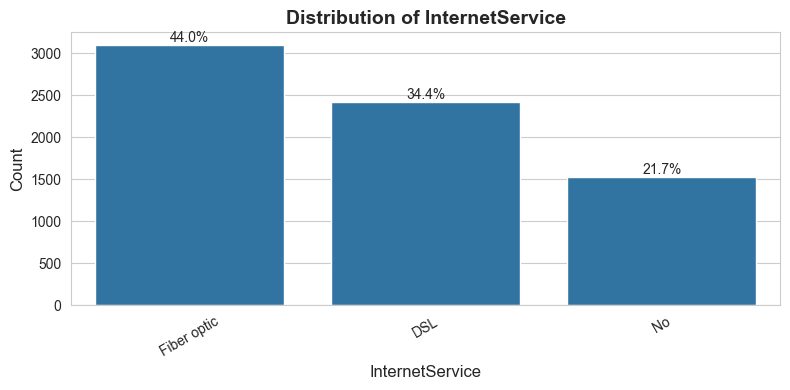

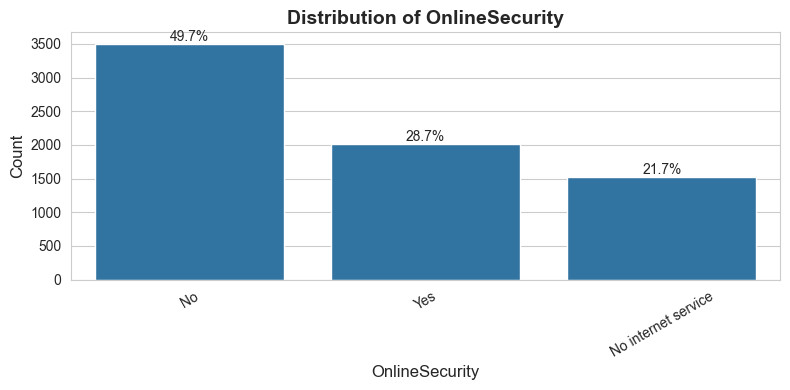

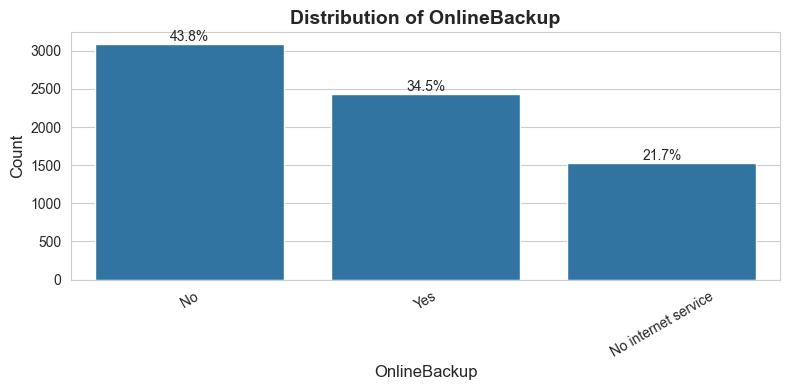

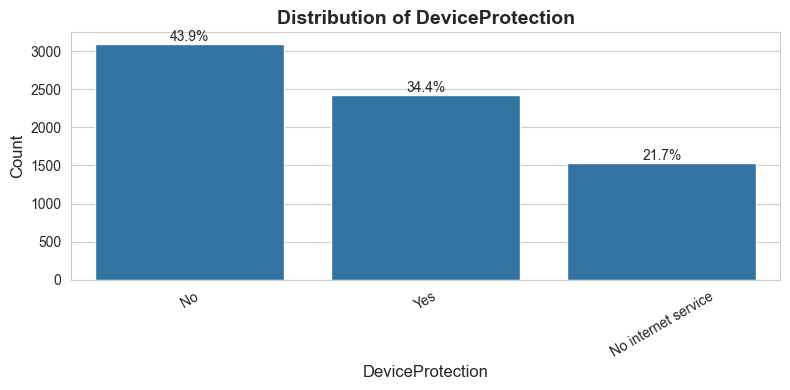

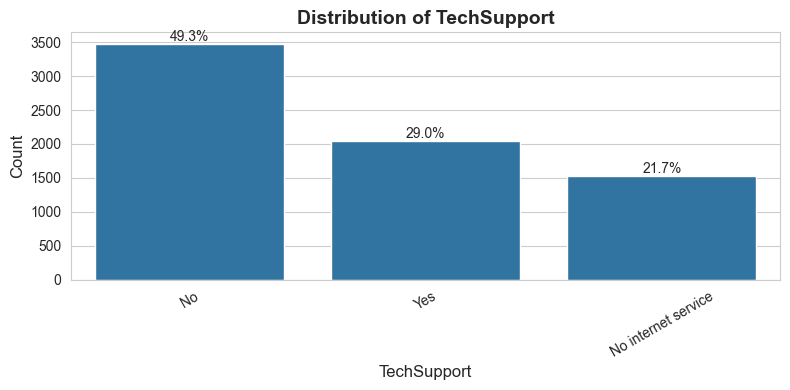

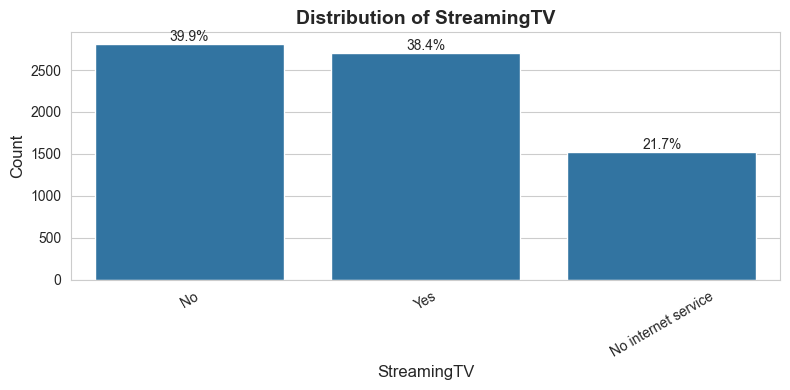

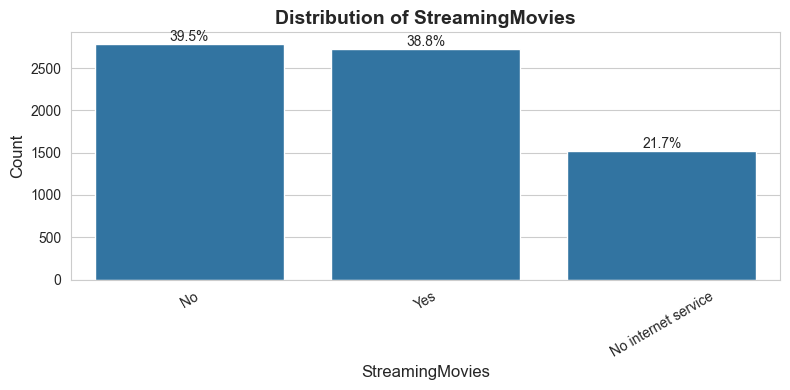

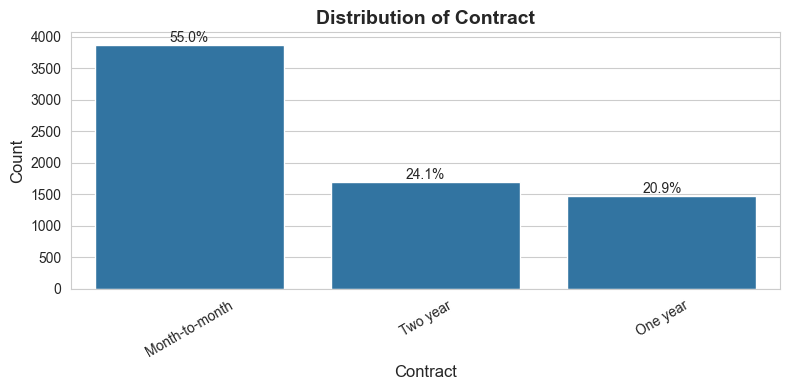

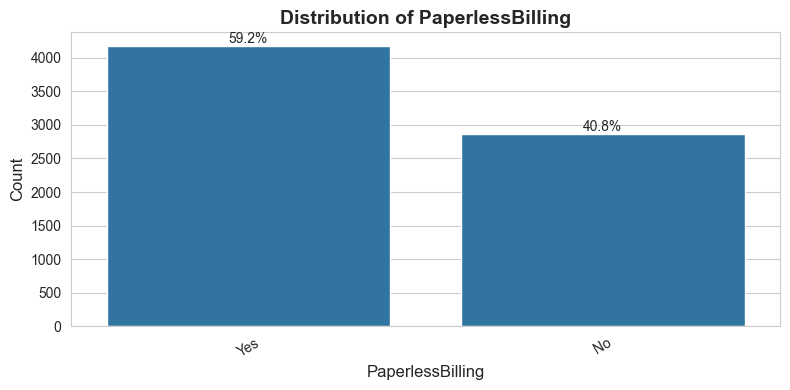

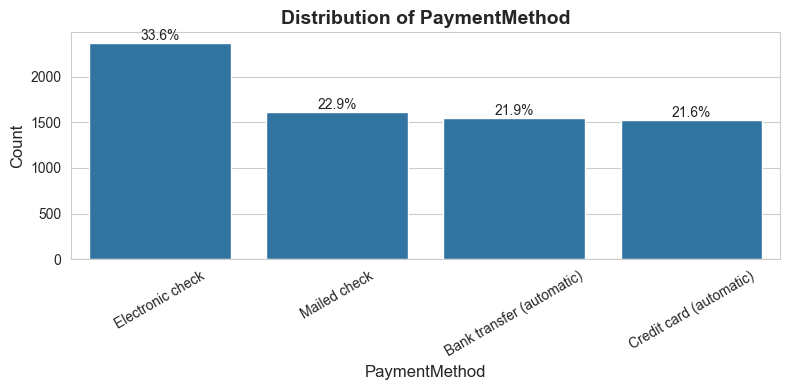

In [20]:


sns.set_style("whitegrid")

for col in categorical_cols:

    plt.figure(figsize=(8, 4))

    ax = sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    total = len(df)

    for p in ax.patches:
        percentage = 100 * p.get_height() / total

        ax.annotate(
            f'{percentage:.1f}%',
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

# The dataset is demographically balanced by gender but contains a higher proportion of customers without dependents.
## 1. Phone service adoption is nearly universal among customers.
## 2. Fiber optic internet is the dominant internet service type.
## 3. Additional services such as online security and tech support have relatively low adoption rates.
## 4. Streaming services have moderate adoption and are evenly split between users and non-users.
## 5. More than half of customers prefer flexible month-to-month contracts.
## 6. Paperless billing is the preferred billing method, and electronic check is the most frequently used payment option.

### Demographics Analysis (Phase 2)

In [21]:
# columns gender,SeniorCitizen,Partner,Dependents with respect to churn
demographic_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents'
]
df['SeniorCitizen'] = df['SeniorCitizen'].map({
    0: 'No',
    1: 'Yes'
})



# A. Churn Distribution by demographic features

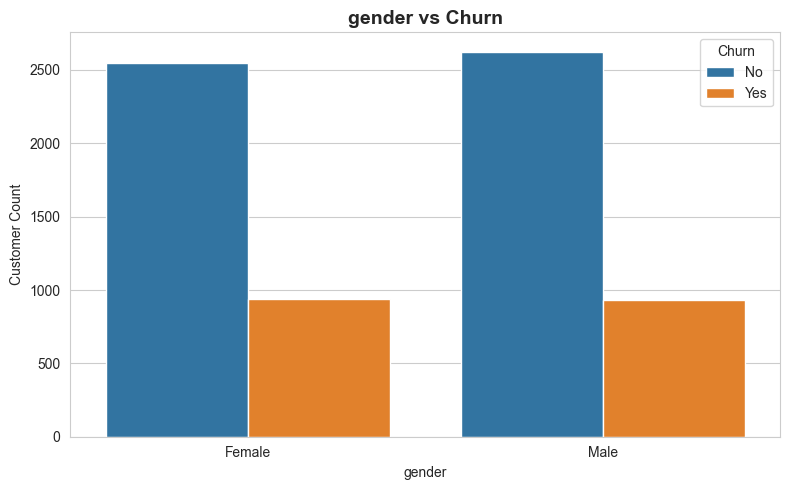

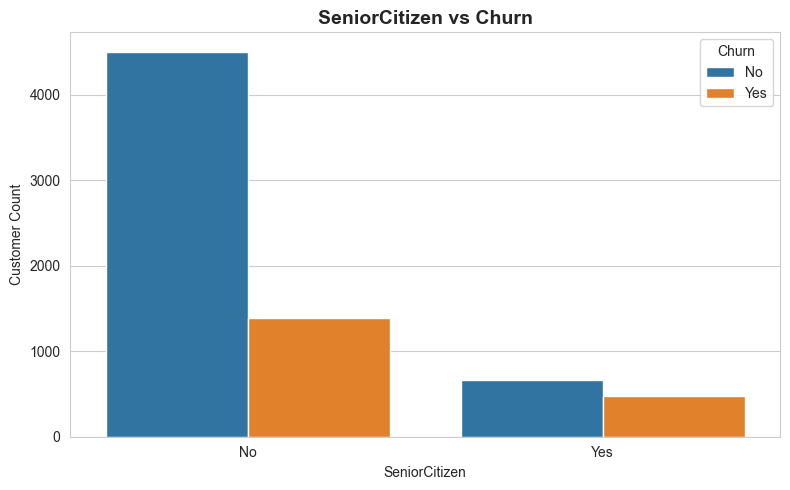

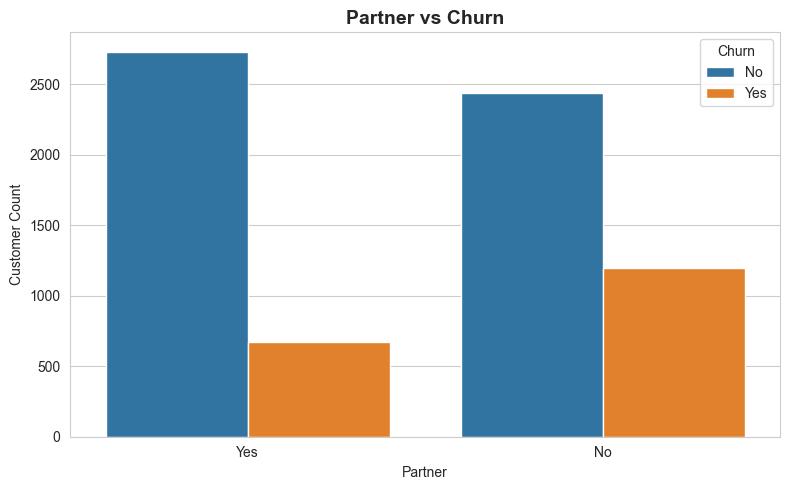

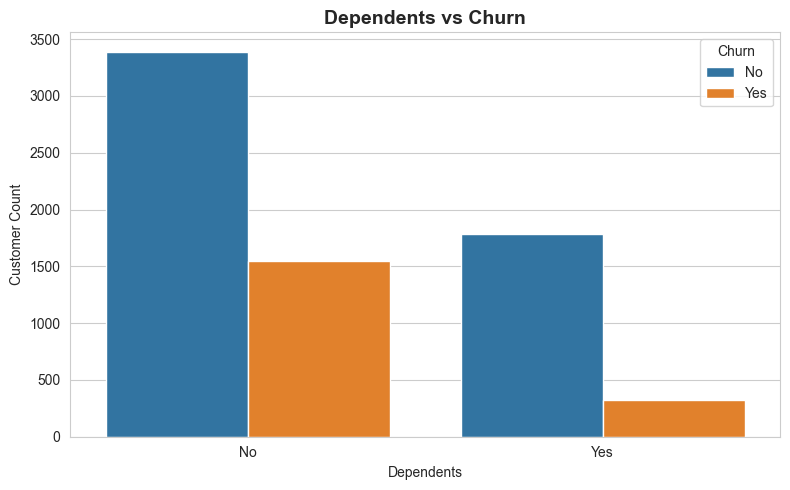

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in demographic_cols:

    plt.figure(figsize=(8,5))

    ax = sns.countplot(
        data=df,
        x=col,
        hue='Churn'
    )

    plt.title(f'{col} vs Churn', fontsize=14, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Customer Count')

    plt.legend(title='Churn')

    plt.tight_layout()
    plt.show()